## 📈 01 — Linear Regression

**What it does:** Finds the best fit line to predict a continuous output.  
**Best used when:** Input-output relationship is roughly linear.  
**Dataset:** California Housing (built into scikit-learn)  
**Algorithm type:** Supervised → Regression  
**Key metrics:** R² Score, MSE, RMSE  
**Model saved as:** `models/linear_regression.pkl`

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pickle
import os

In [4]:
# Load Dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

print("shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

shape: (20640, 9)

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
# Basic Stats
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [7]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())

Missing values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


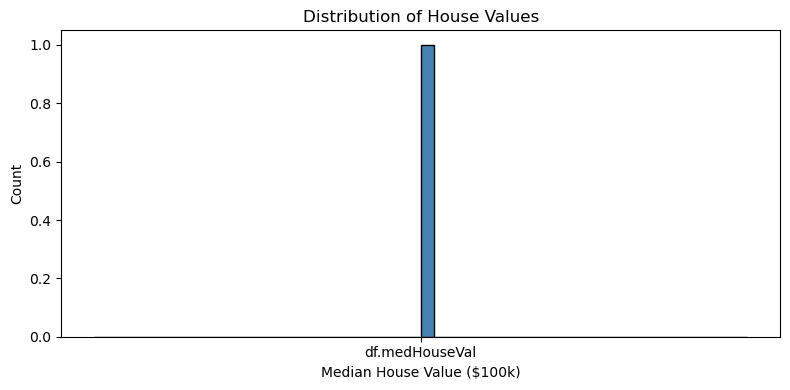

In [9]:
# Distribution of target variable
plt.figure(figsize=(8, 4))
plt.hist(['df.medHouseVal'], bins=50, color='steelblue', edgecolor='black')
plt.title("Distribution of House Values")
plt.xlabel("Median House Value ($100k)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


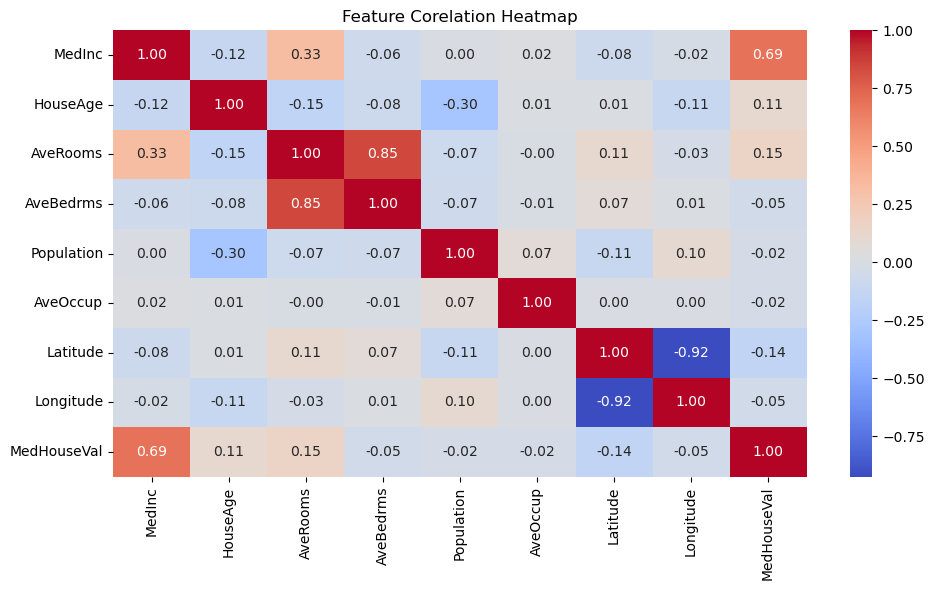

In [10]:
# Corelation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Feature Corelation Heatmap")
plt.tight_layout()
plt.show()

In [11]:
# Split features and target
X = df.drop("MedHouseVal", axis = 1)
y = df["MedHouseVal"]

# Train test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size =0.2, random_state = 42
)

print("Training samples:", X_train.shape[0])
print("Testing samplaes:", X_test.shape[0])

Training samples: 16512
Testing samplaes: 4128


In [12]:
# Train Linear Regression model 
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained succesfully")

Model trained succesfully


In [13]:
# Predictions
y_pred = model.predict(X_test)

# Metrics 
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")  

MSE  : 0.5559
RMSE : 0.7456
R2   : 0.5758


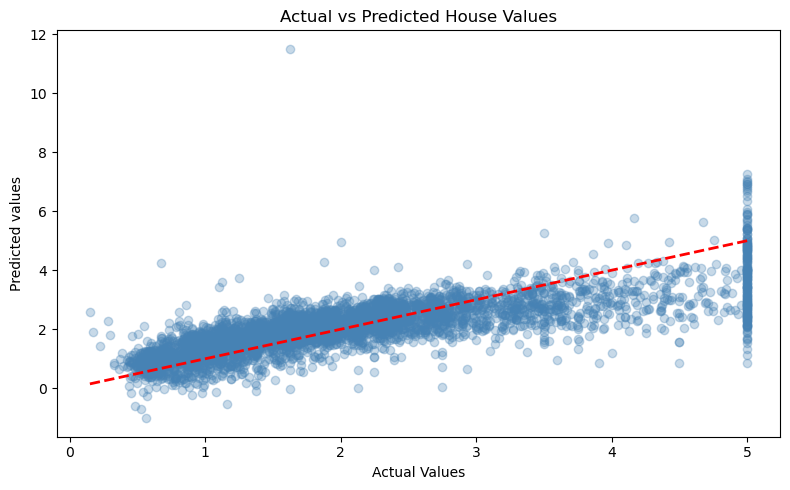

In [15]:
# Actual vs Predicted
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha = 0.3, color = 'steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth = 2)
plt.title("Actual vs Predicted House Values")
plt.xlabel("Actual Values")
plt.ylabel("Predicted values")
plt.title('Actual vs Predicted House Values')
plt.tight_layout()
plt.show()

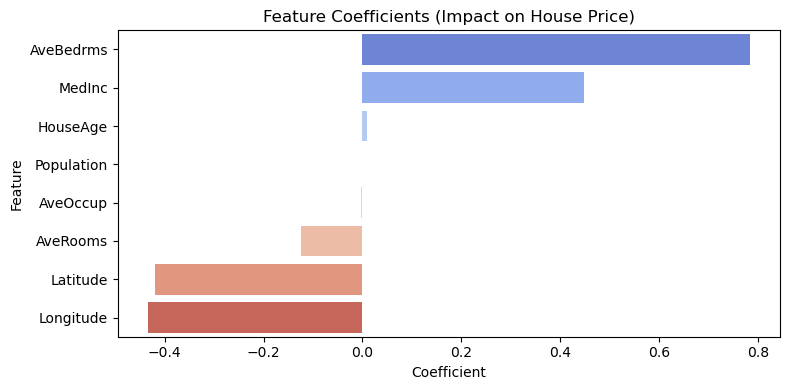

In [22]:
# Feature importance (coefficients)
coef_df = pd.DataFrame({
    'Feature': housing.feature_names,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='coolwarm',hue='Feature', legend=False)
plt.title('Feature Coefficients (Impact on House Price)')
plt.tight_layout()
plt.show()

In [ ]:
# Create models folder if not exists
os.makedirs('models', exist_ok=True)

# Save model
with open('01_linear_regression/linear_regression.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved to 01_linear_regression/linear_regression.pkl")

Model saved to models/linear_regression.pkl


## ✅ Summary

| Metric | Value |
|--------|-------|
| R² Score | ~0.57 |
| RMSE | ~0.74 |
| Training Samples | 16,512 |
| Testing Samples | 4,128 |

**What I learned:**
- Linear Regression fits a line minimizing squared errors
- MedInc (income) is the strongest predictor of house price
- R² of 0.57 means the model explains 57% of variance
- For better accuracy → try Ridge, Lasso, or Random Forest next